In [1]:
#importing Libraries 
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

c:\Users\vshru\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df =dataset['train'].to_pandas()


In [3]:
#Data Cleanup
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])

In [4]:

df['job_skills'] = df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x)else x)

In [8]:
type(df['job_skills'][1])

list

In [ ]:
#Transform each element of a list-like to a row, replicating index values.
df[['job_title_short','job_skills']].head(5)

,job_title_short,job_skills
0,Senior Data Engineer,NaN
1,Data Analyst,"[r, python, sql, nosql, power bi, tableau]"
2,Data Engineer,"[python, sql, c#, azure, airflow, dax, docker,..."
3,Data Engineer,"[python, c++, java, matlab, aws, tensorflow, k..."
4,Data Engineer,"[bash, python, oracle, aws, ansible, puppet, j..."


In [ ]:
help(df.explode)

In [10]:
df_exploded=df.explode('job_skills').copy()

<Axes: xlabel='job_skills'>

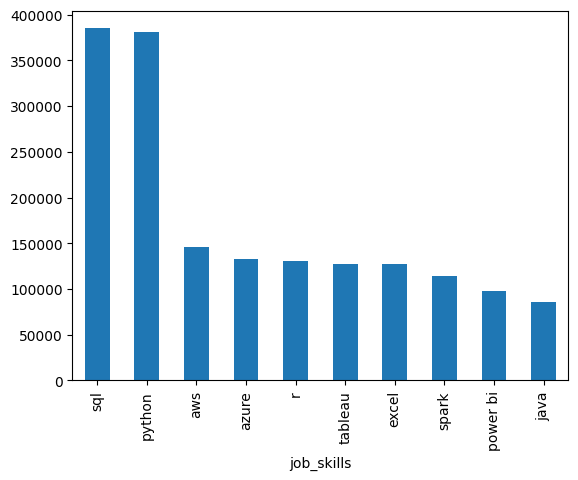

In [22]:
df_exploded['job_skills'].value_counts().head(10).plot(kind = 'bar')

In [17]:
skills_count =df_exploded.groupby(['job_title_short','job_skills']).size()

In [18]:
type(skills_count)

pandas.Series

In [25]:
#convert series into dataframe 
df_skills_count = skills_count.reset_index(name = 'skill_count')

In [27]:
df_skills_count = df_skills_count.sort_values(by = 'skill_count',ascending=False)

In [28]:
df_skills_count

,job_title_short,job_skills,skill_count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
462,Data Analyst,chainer,1
432,Cloud Engineer,wrike,1
410,Cloud Engineer,theano,1
24,Business Analyst,chainer,1


In [45]:
job_title = 'Data Analyst'

In [52]:
top_skills = 15

In [54]:
df_skill_final = df_skills_count[df_skills_count['job_title_short']==job_title].head(top_skills)

In [47]:
df_skill_final

,job_title_short,job_skills,skill_count
625,Data Analyst,sql,92428
494,Data Analyst,excel,66860
590,Data Analyst,python,57190
638,Data Analyst,tableau,46455
583,Data Analyst,power bi,39380
594,Data Analyst,r,29996
606,Data Analyst,sas,27998
585,Data Analyst,powerpoint,13822
664,Data Analyst,word,13562
605,Data Analyst,sap,11280


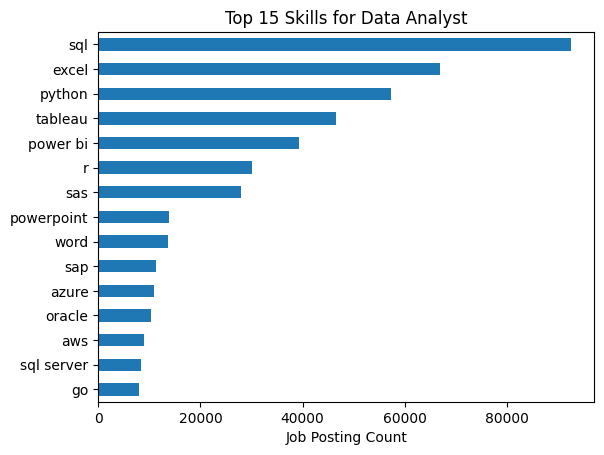

In [55]:
df_skill_final.plot(kind = 'barh',x ='job_skills',y='skill_count')
plt.gca().invert_yaxis()
plt.title(f"Top {top_skills} Skills for {job_title}")
plt.xlabel("Job Posting Count")
plt.ylabel("")
plt.legend().set_visible(False)
plt.show()
